# Kubernetes vs. Simulator Evaluation

This notebook reproduces the final evaluation cycle combining the Kubernetes replay
and the simulator runs. It loads the exported scheduling traces, harmonises the
schema, computes summary metrics, and visualises the trade-offs across policies with
Pareto-front analysis.

The workflow follows the architecture notes in Chapter 5.3.2 of the design document:

1. Select the runs and fetch the traces.
2. Harmonise the per-job schema and enrich it with timing features.
3. Optionally pull contextual metrics (left as hooks for Prometheus integration).
4. Produce visual comparisons and Pareto-front inspection.

## 1. Imports and helper utilities

The helpers below keep the notebook self-contained: they resolve the repository
root automatically, standardise datetime conversions, and expose a Pareto-front
filter for the multi-objective analysis.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
import json
import re
from collections import Counter
from textwrap import dedent

plt.style.use("seaborn-v0_8")


def find_repo_root(start: Path | None = None) -> Path:
    start = Path(start or Path.cwd()).resolve()
    for parent in [start, *start.parents]:
        if (parent / ".git").exists():
            return parent
    raise RuntimeError("Could not locate repository root from" f" {start}")


def safe_to_datetime(series: pd.Series) -> pd.Series:
    # Convert string timestamps to timezone-aware pandas datetimes. Placeholder
    # values such as 0001-01-01 are mapped to NaT so downstream metrics can drop them.
    cleaned = series.replace({"": pd.NA, "0001-01-01T00:00:00Z": pd.NA})
    return pd.to_datetime(cleaned, utc=True, errors="coerce")


def compute_wait_seconds(submit: pd.Series, start: pd.Series) -> pd.Series:
    wait = (start - submit).dt.total_seconds()
    return wait


def compute_runtime_seconds(start: pd.Series, end: pd.Series) -> pd.Series:
    runtime = (end - start).dt.total_seconds()
    return runtime


def pareto_front(points: np.ndarray) -> np.ndarray:
    # Return a boolean mask for the Pareto-efficient points (minimisation).
    if points.ndim != 2:
        raise ValueError("Pareto front expects a 2D array")
    n_points = points.shape[0]
    is_efficient = np.ones(n_points, dtype=bool)
    for i in range(n_points):
        if not is_efficient[i]:
            continue
        dominated = np.all(points <= points[i], axis=1) & np.any(points < points[i], axis=1)
        is_efficient &= ~dominated
    return is_efficient


repo_root = find_repo_root()
repo_root

PosixPath('/home/goncalo/KubeEnergyScheduler')

## 2. Locate experiment artefacts

Both the simulator and the Kubernetes replay export CSV/JSON artefacts. Update the
paths below if you want to compare different runs.

In [2]:
# Simulator artefacts (per-job traces + summary metrics)
sim_dir = repo_root / "kubenergysched" / "results" / "results_20251022_090851"
sim_summary_path = sim_dir / "summary.csv"

# Kubernetes replay decisions (JSONL + optional CSV projection)
k8_decisions_jsonl = repo_root / "decisions.jsonl"
k8_decisions_csv = repo_root / "decisions.csv"

sim_dir, sim_summary_path, k8_decisions_jsonl, k8_decisions_csv

(PosixPath('/home/goncalo/KubeEnergyScheduler/kubenergysched/results/results_20251022_090851'),
 PosixPath('/home/goncalo/KubeEnergyScheduler/kubenergysched/results/results_20251022_090851/summary.csv'),
 PosixPath('/home/goncalo/KubeEnergyScheduler/decisions.jsonl'),
 PosixPath('/home/goncalo/KubeEnergyScheduler/decisions.csv'))

## 3. Load simulator traces

The simulator stores one CSV per scheduler/policy configuration with per-job
records. We consolidate them into a single `DataFrame` and derive the wait/runtime
features required for the comparisons. The aggregated metrics are loaded from the
`summary.csv` file emitted at the end of the simulation batch.

In [3]:
sim_per_job_frames: List[pd.DataFrame] = []

for csv_path in sorted(sim_dir.glob("*_results.csv")):
    if csv_path.name == "summary.csv":
        continue
    df = pd.read_csv(csv_path)
    # Ensure the common schema
    df["submit"] = pd.to_datetime(df["submit"], utc=True, errors="coerce")
    df["start"] = pd.to_datetime(df["start"], utc=True, errors="coerce")
    df["end"] = pd.to_datetime(df["end"], utc=True, errors="coerce")
    df["wait_s"] = df["wait_ms"].astype(float) / 1000.0
    df["runtime_s"] = compute_runtime_seconds(df["start"], df["end"])
    df["source"] = "simulator"

    # Add identifiers extracted from the filename (policy + configuration)
    base_name, ci_weight, batch_size, _ = csv_path.stem.rsplit("_", 3)
    df["policy"] = base_name
    df["ci_weight"] = float(ci_weight)
    df["batch_size"] = int(batch_size)
    sim_per_job_frames.append(df)

sim_per_job = pd.concat(sim_per_job_frames, ignore_index=True)
sim_per_job.head()

,sched,job_id,node,submit,start,end,wait_ms,ci_cost,wait_s,runtime_s,source,policy,ci_weight,batch_size
0,carbonscaler,job-0,gpu-0,2025-10-19 15:00:00+00:00,2025-10-19 15:00:00+00:00,2025-10-19 15:02:05+00:00,0,0.000282,0.0,125.0,simulator,carbonscaler,0.05,32
1,carbonscaler,job-1,burst-0,2025-10-19 15:00:00+00:00,2025-10-19 15:00:00+00:00,2025-10-19 15:09:46+00:00,0,0.003540,0.0,586.0,simulator,carbonscaler,0.05,32
2,carbonscaler,job-2,burst-1,2025-10-19 15:00:00+00:00,2025-10-19 15:00:00+00:00,2025-10-19 15:03:27+00:00,0,0.003450,0.0,207.0,simulator,carbonscaler,0.05,32
3,carbonscaler,job-3,gpu-0,2025-10-19 15:00:03+00:00,2025-10-19 15:02:05+00:00,2025-10-19 15:02:47+00:00,122000,0.000117,122.0,42.0,simulator,carbonscaler,0.05,32
4,carbonscaler,job-4,gpu-0,2025-10-19 15:00:04+00:00,2025-10-19 15:02:05+00:00,2025-10-19 15:11:11+00:00,121000,0.002431,121.0,546.0,simulator,carbonscaler,0.05,32


In [4]:
sim_summary = pd.read_csv(sim_summary_path)
sim_summary["source"] = "simulator"
sim_summary

,policy,ci_weight,batch_size,total_ci_cost_g,avg_ci_per_job_g,cfp_g_per_cpu_hour,avg_wait_s,makespan_s,elapsed_ms,num_jobs,alpha_mass,lookahead_min,duration_scale,duration_overrides,source
0,engine,0.05,32,2.192427,0.002192,0.004712,6302.187,20782.0,2242.0,1000,1.0,0,1.0,NaN,simulator
1,k8,0.05,32,2.152143,0.002152,0.004625,6350.138,21460.0,727.0,1000,1.0,0,1.0,NaN,simulator
2,carbonscaler,0.05,32,2.112778,0.002113,0.004541,6530.895,22121.0,958.0,1000,1.0,0,1.0,NaN,simulator
3,themis_base,0.05,32,2.149033,0.002149,0.004619,6451.196,21554.0,716.0,1000,1.0,0,1.0,NaN,simulator
4,het-weighted-sum,0.05,32,2.139317,0.002139,0.004598,6451.145,21739.0,1431.0,1000,1.0,0,1.0,NaN,simulator


## 4. Load Kubernetes replay decisions

The controller exports one JSONL record per scheduling decision. The snippet below
filters Kubernetes-native results (`result_type == "kub_result"`), converts the
timestamps, and derives wait/runtime metrics to mirror the simulator schema.

In [5]:
k8_sources = []

if k8_decisions_jsonl.exists():
    k8_sources.append(k8_decisions_jsonl)

extra_k8_dirs = [
    repo_root / "analysis" / "k8s_runs",
    repo_root / "analysis" / "kubernetes_runs",
    repo_root / "k8s" / "runs",
    repo_root / "k8s" / "experiments",
]

for base_dir in extra_k8_dirs:
    if base_dir.exists():
        for candidate in sorted(base_dir.glob("**/*.jsonl")):
            if candidate.name.startswith("."):
                continue
            k8_sources.append(candidate)

seen_paths: set[Path] = set()
ordered_sources: list[Path] = []
for path in k8_sources:
    path = path.resolve()
    if not path.exists() or path in seen_paths:
        continue
    seen_paths.add(path)
    ordered_sources.append(path)


def _infer_run_id(path: Path) -> str:
    try:
        rel = path.relative_to(repo_root)
    except ValueError:
        rel = path
    parts: list[str] = []
    if rel.parent != Path('.'):
        parts.append(rel.parent.as_posix().replace('/', '__'))
    stem = rel.stem or rel.name
    if stem == "decisions" and rel.parent != Path('.'):
        stem = rel.parent.name
    parts.append(stem)
    run_id = "__".join([p for p in parts if p])
    return run_id or path.stem


def _load_sidecar_metadata(path: Path) -> dict:
    for meta_candidate in [
        path.with_suffix(".metadata.json"),
        path.with_suffix(".meta.json"),
        path.with_name("metadata.json"),
    ]:
        if meta_candidate.exists():
            try:
                return json.loads(meta_candidate.read_text())
            except Exception:
                return {}
    return {}


def _series_or_empty(df: pd.DataFrame, column: str) -> pd.Series:
    if column in df.columns:
        return df[column]
    return pd.Series(index=df.index, dtype=object)


k8_runs = []
for path in ordered_sources:
    try:
        df = pd.read_json(path, lines=True)
    except ValueError:
        continue
    df = df.query("result_type == 'kub_result'").copy()
    if df.empty:
        continue

    meta = _load_sidecar_metadata(path)
    run_id = str(meta.get("run_id") or _infer_run_id(path))
    label = str(meta.get("label") or meta.get("name") or run_id)

    for weight_key in ("theta_e", "theta_c"):
        if weight_key not in meta and weight_key in df.columns:
            values = df[weight_key].dropna().unique()
            if len(values) == 1:
                try:
                    meta[weight_key] = float(values[0])
                except (TypeError, ValueError):
                    meta[weight_key] = values[0]

    df["run_id"] = run_id
    df["run_label"] = label
    for key, value in meta.items():
        if key in {"run_id", "label", "name"}:
            continue
        df[key] = value

    k8_runs.append(
        {
            "path": path,
            "run_id": run_id,
            "label": label,
            "metadata": meta,
            "frame": df,
        }
    )

k8_run_metadata = {
    run["run_id"]: {k: v for k, v in run.items() if k != "frame"}
    for run in k8_runs
}

if k8_runs:
    k8_decisions = pd.concat([run["frame"] for run in k8_runs], ignore_index=True)
else:
    k8_decisions = pd.DataFrame(
        columns=[
            "result_type",
            "result_id",
            "scheduler",
            "source",
            "job_id",
            "site",
            "node",
            "e_norm",
            "c_norm",
            "cost",
            "theta_e",
            "theta_c",
            "forecast_used",
            "fallback",
            "reject_reason",
            "queued_at",
            "started_at",
            "ended_at",
            "run_id",
            "run_label",
        ]
    )

k8_decisions["submit"] = safe_to_datetime(_series_or_empty(k8_decisions, "queued_at"))
k8_decisions["start"] = safe_to_datetime(_series_or_empty(k8_decisions, "started_at"))
k8_decisions["end"] = safe_to_datetime(_series_or_empty(k8_decisions, "ended_at"))

k8_decisions["wait_s"] = compute_wait_seconds(k8_decisions["submit"], k8_decisions["start"])
k8_decisions["runtime_s"] = compute_runtime_seconds(k8_decisions["start"], k8_decisions["end"])

if "scheduler" in k8_decisions.columns:
    k8_decisions["policy"] = k8_decisions["scheduler"]
else:
    k8_decisions["policy"] = "unknown"
k8_decisions["source"] = "kubernetes"

k8_decisions[
    [
        "result_id",
        "run_id",
        "run_label",
        "scheduler",
        "job_id",
        "site",
        "node",
        "wait_s",
        "runtime_s",
        "fallback",
        "cost",
    ]
].head()


,result_id,run_id,run_label,scheduler,job_id,site,node,wait_s,runtime_s,fallback,cost
0,kub_result_377704a9-aa1d-4c6d-bcb5-e4d70a75fd15,decisions,decisions,engine,377704a9-aa1d-4c6d-bcb5-e4d70a75fd15,,,NaN,NaN,True,0.0
1,kub_result_c12af999-ebdb-40b4-a2da-49c8876d5796,decisions,decisions,engine,c12af999-ebdb-40b4-a2da-49c8876d5796,,,NaN,NaN,True,0.0
2,kub_result_0264426d-50b3-4100-ac74-111d0588ee77,decisions,decisions,engine,0264426d-50b3-4100-ac74-111d0588ee77,,,NaN,NaN,True,0.0
3,kub_result_6703b11e-1bec-42df-94e4-8538e9528bcf,decisions,decisions,engine,6703b11e-1bec-42df-94e4-8538e9528bcf,,,NaN,NaN,True,0.0
4,kub_result_95d0ac44-b2fb-4aa3-b588-a5dbb5f40612,decisions,decisions,engine,95d0ac44-b2fb-4aa3-b588-a5dbb5f40612,,,NaN,NaN,True,0.0


## 5. Harmonise schemas

To compare the two environments we keep only the shared columns and annotate the
origin. The helper below produces a tidy table that concatenates simulator and
Kubernetes traces.

In [6]:
common_cols = [
    "source",
    "run_id",
    "run_label",
    "policy",
    "job_id",
    "site",
    "node",
    "submit",
    "start",
    "end",
    "wait_s",
    "runtime_s",
    "ci_cost",
]

sim_view = sim_per_job.copy()
if "policy" not in sim_view.columns:
    sim_view["policy"] = sim_view["sched"]
if "sched" in sim_view.columns:
    sim_view = sim_view.drop(columns=["sched"])
for col in ["site", "node"]:
    if col not in sim_view:
        sim_view[col] = pd.NA
sim_view["ci_cost"] = sim_view["ci_cost"].astype(float)
if "run_id" not in sim_view.columns:
    ci_str = sim_view.get("ci_weight", pd.Series(0.0, index=sim_view.index)).map(lambda v: f"{v:.2f}" if pd.notna(v) else "na")
    batch_str = sim_view.get("batch_size", pd.Series(0, index=sim_view.index)).astype(str)
    sim_view["run_id"] = (
        sim_view["policy"].astype(str)
        + "|ci="
        + ci_str
        + "|batch="
        + batch_str
    )
if "run_label" not in sim_view.columns:
    if {"ci_weight", "batch_size"}.issubset(sim_view.columns):
        sim_view["run_label"] = (
            sim_view["policy"].astype(str)
            + " (ci="
            + sim_view["ci_weight"].map(lambda v: f"{v:.2f}" if pd.notna(v) else "?")
            + ", batch="
            + sim_view["batch_size"].astype(str)
            + ")"
        )
    else:
        sim_view["run_label"] = sim_view["policy"].astype(str)

k8_view = k8_decisions.copy()
if "ci_cost" not in k8_view.columns:
    k8_view["ci_cost"] = k8_view.get("cost", 0.0)
if "run_id" not in k8_view.columns:
    k8_view["run_id"] = k8_view["policy"].astype(str)
if "run_label" not in k8_view.columns:
    label_cols = [col for col in ("run_label", "label") if col in k8_view.columns]
    if label_cols:
        k8_view["run_label"] = k8_view[label_cols[0]]
    else:
        k8_view["run_label"] = k8_view["run_id"]

combined = pd.concat(
    [sim_view[common_cols], k8_view[common_cols]],
    ignore_index=True,
    sort=False,
)
combined.head()


,source,run_id,run_label,policy,job_id,site,node,submit,start,end,wait_s,runtime_s,ci_cost
0,simulator,carbonscaler|ci=0.05|batch=32,"carbonscaler (ci=0.05, batch=32)",carbonscaler,job-0,NaN,gpu-0,2025-10-19 15:00:00+00:00,2025-10-19 15:00:00+00:00,2025-10-19 15:02:05+00:00,0.0,125.0,0.000282
1,simulator,carbonscaler|ci=0.05|batch=32,"carbonscaler (ci=0.05, batch=32)",carbonscaler,job-1,NaN,burst-0,2025-10-19 15:00:00+00:00,2025-10-19 15:00:00+00:00,2025-10-19 15:09:46+00:00,0.0,586.0,0.003540
2,simulator,carbonscaler|ci=0.05|batch=32,"carbonscaler (ci=0.05, batch=32)",carbonscaler,job-2,NaN,burst-1,2025-10-19 15:00:00+00:00,2025-10-19 15:00:00+00:00,2025-10-19 15:03:27+00:00,0.0,207.0,0.003450
3,simulator,carbonscaler|ci=0.05|batch=32,"carbonscaler (ci=0.05, batch=32)",carbonscaler,job-3,NaN,gpu-0,2025-10-19 15:00:03+00:00,2025-10-19 15:02:05+00:00,2025-10-19 15:02:47+00:00,122.0,42.0,0.000117
4,simulator,carbonscaler|ci=0.05|batch=32,"carbonscaler (ci=0.05, batch=32)",carbonscaler,job-4,NaN,gpu-0,2025-10-19 15:00:04+00:00,2025-10-19 15:02:05+00:00,2025-10-19 15:11:11+00:00,121.0,546.0,0.002431


## 6. Summary metrics per environment

The next cells compute aggregate indicators (number of jobs, completion ratio,
carbon impact, wait time, fallback rate) to sanity-check the two datasets before
digging into the Pareto analysis.

In [7]:
def summarise_jobs(df: pd.DataFrame) -> pd.Series:
    completed = df["end"].notna()
    submit = df["submit"].dropna()
    end_times = df.loc[completed, "end"]
    makespan = (end_times.max() - submit.min()).total_seconds() if not end_times.empty and not submit.empty else np.nan
    return pd.Series({
        "jobs": len(df),
        "completed_jobs": int(completed.sum()),
        "completion_ratio": completed.mean() if len(df) else np.nan,
        "fallback_ratio": df.get("fallback", pd.Series(dtype=float)).mean() if "fallback" in df else np.nan,
        "total_ci_cost_g": df["ci_cost"].sum(),
        "avg_ci_per_job_g": df["ci_cost"].mean(),
        "avg_wait_s": df["wait_s"].mean(),
        "avg_runtime_s": df["runtime_s"].mean(),
        "makespan_s": makespan,
    })
summary_by_source = (
    combined.groupby(["source", "run_id", "run_label", "policy"], dropna=False, group_keys=False)
    .apply(summarise_jobs, include_groups=False)
    .reset_index()
)
summary_by_source


,source,run_id,run_label,policy,jobs,completed_jobs,completion_ratio,fallback_ratio,total_ci_cost_g,avg_ci_per_job_g,avg_wait_s,avg_runtime_s,makespan_s
0,kubernetes,decisions,decisions,engine,70.0,0.0,0.0,NaN,0.025691,0.000367,NaN,NaN,NaN
1,simulator,carbonscaler|ci=0.05|batch=32,"carbonscaler (ci=0.05, batch=32)",carbonscaler,1000.0,1000.0,1.0,NaN,2.112764,0.002113,6530.895,238.017,22121.0
2,simulator,engine|ci=0.05|batch=32,"engine (ci=0.05, batch=32)",engine,1000.0,1000.0,1.0,NaN,2.192427,0.002192,6302.187,238.017,20782.0
3,simulator,het-weighted-sum|ci=0.05|batch=32,"het-weighted-sum (ci=0.05, batch=32)",het-weighted-sum,1000.0,1000.0,1.0,NaN,2.139326,0.002139,6451.145,238.017,21739.0
4,simulator,k8|ci=0.05|batch=32,"k8 (ci=0.05, batch=32)",k8,1000.0,1000.0,1.0,NaN,2.152157,0.002152,6350.138,238.017,21460.0
5,simulator,themis_base|ci=0.05|batch=32,"themis_base (ci=0.05, batch=32)",themis_base,1000.0,1000.0,1.0,NaN,2.149034,0.002149,6451.196,238.017,21554.0


The simulator additionally exposes rich metadata (configuration weights, elapsed
simulation time) via `summary.csv`. Joining that file with the per-job aggregates
helps confirm consistency and provides the inputs for the Pareto plot.

In [8]:
sim_summary_metrics = summary_by_source.query("source == 'simulator'").merge(
    sim_summary,
    on=["policy"],
    how="left",
    suffixes=("_jobs", "_reported"),
)
sim_summary_metrics = sim_summary_metrics.rename(
    columns={
        "total_ci_cost_g_jobs": "total_ci_cost_g_from_jobs",
        "avg_wait_s_jobs": "avg_wait_s_from_jobs",
        "total_ci_cost_g_reported": "total_ci_cost_g_reported",
        "avg_wait_s_reported": "avg_wait_s_reported",
    }
)
sim_summary_metrics[[
    "policy",
    "jobs",
    "total_ci_cost_g_from_jobs",
    "total_ci_cost_g_reported",
    "avg_wait_s_from_jobs",
    "avg_wait_s_reported",
]]

,policy,jobs,total_ci_cost_g_from_jobs,total_ci_cost_g_reported,avg_wait_s_from_jobs,avg_wait_s_reported
0,carbonscaler,1000.0,2.112764,2.112778,6530.895,6530.895
1,engine,1000.0,2.192427,2.192427,6302.187,6302.187
2,het-weighted-sum,1000.0,2.139326,2.139317,6451.145,6451.145
3,k8,1000.0,2.152157,2.152143,6350.138,6350.138
4,themis_base,1000.0,2.149034,2.149033,6451.196,6451.196


## 7. Visual comparisons

We now contrast the average wait times and carbon footprint of each policy. The
Kubernetes replay (engine) is highlighted separately; because the sampled trace only
contains fallback decisions, the wait/runtime metrics stay undefined (`NaN`).

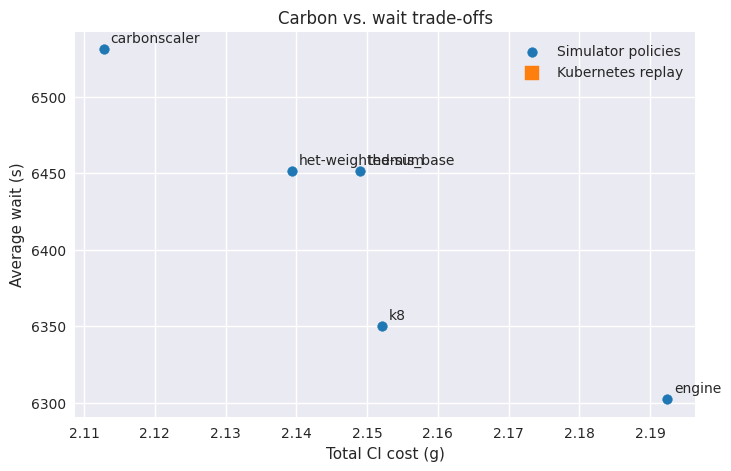

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sim_points = sim_summary_metrics.sort_values("total_ci_cost_g_from_jobs")
ax.scatter(
    sim_points["total_ci_cost_g_from_jobs"],
    sim_points["avg_wait_s_from_jobs"],
    label="Simulator policies",
    c="tab:blue",
)
for _, row in sim_points.iterrows():
    ax.annotate(row["policy"], (row["total_ci_cost_g_from_jobs"], row["avg_wait_s_from_jobs"]), textcoords="offset points", xytext=(5, 5))
k8_summary = summary_by_source.query("source == 'kubernetes'")
if not k8_summary.empty:
    ax.scatter(
        k8_summary["total_ci_cost_g"],
        k8_summary["avg_wait_s"],
        label="Kubernetes replay",
        marker="s",
        c="tab:orange",
        s=90,
    )
    for _, row in k8_summary.iterrows():
        ax.annotate(
            f"k8s:{row['policy']}",
            (row["total_ci_cost_g"], row["avg_wait_s"]),
            textcoords="offset points",
            xytext=(5, -12),
        )
ax.set_xlabel("Total CI cost (g)")
ax.set_ylabel("Average wait (s)")
ax.set_title("Carbon vs. wait trade-offs")
ax.legend()
plt.show()

## 8. Pareto-front analysis

The Pareto filter isolates the policies that are non-dominated with respect to
(total carbon, average wait). These are the options worth keeping when searching
for better baselines or new algorithms.

In [10]:
pareto_metrics = sim_points[["total_ci_cost_g_from_jobs", "avg_wait_s_from_jobs"]].to_numpy()
mask = pareto_front(pareto_metrics)
pareto_candidates = sim_points.loc[mask].copy()
pareto_candidates

,source_jobs,run_id,run_label,policy,jobs,completed_jobs,completion_ratio,fallback_ratio,total_ci_cost_g_from_jobs,avg_ci_per_job_g_jobs,...,cfp_g_per_cpu_hour,avg_wait_s_reported,makespan_s_reported,elapsed_ms,num_jobs,alpha_mass,lookahead_min,duration_scale,duration_overrides,source_reported
0,simulator,carbonscaler|ci=0.05|batch=32,"carbonscaler (ci=0.05, batch=32)",carbonscaler,1000.0,1000.0,1.0,NaN,2.112764,0.002113,...,0.004541,6530.895,22121.0,958.0,1000,1.0,0,1.0,NaN,simulator
4,simulator,themis_base|ci=0.05|batch=32,"themis_base (ci=0.05, batch=32)",themis_base,1000.0,1000.0,1.0,NaN,2.149034,0.002149,...,0.004619,6451.196,21554.0,716.0,1000,1.0,0,1.0,NaN,simulator
3,simulator,k8|ci=0.05|batch=32,"k8 (ci=0.05, batch=32)",k8,1000.0,1000.0,1.0,NaN,2.152157,0.002152,...,0.004625,6350.138,21460.0,727.0,1000,1.0,0,1.0,NaN,simulator
1,simulator,engine|ci=0.05|batch=32,"engine (ci=0.05, batch=32)",engine,1000.0,1000.0,1.0,NaN,2.192427,0.002192,...,0.004712,6302.187,20782.0,2242.0,1000,1.0,0,1.0,NaN,simulator


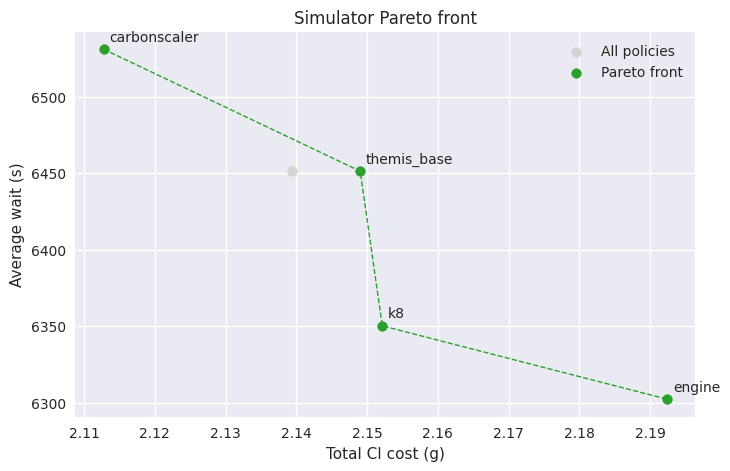

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sim_points["total_ci_cost_g_from_jobs"], sim_points["avg_wait_s_from_jobs"], color="lightgray", label="All policies")
ax.scatter(
    pareto_candidates["total_ci_cost_g_from_jobs"],
    pareto_candidates["avg_wait_s_from_jobs"],
    color="tab:green",
    label="Pareto front",
)
ax.plot(
    pareto_candidates["total_ci_cost_g_from_jobs"],
    pareto_candidates["avg_wait_s_from_jobs"],
    color="tab:green",
    linestyle="--",
    linewidth=1,
)
for _, row in pareto_candidates.iterrows():
    ax.annotate(row["policy"], (row["total_ci_cost_g_from_jobs"], row["avg_wait_s_from_jobs"]), textcoords="offset points", xytext=(4, 6))
ax.set_xlabel("Total CI cost (g)")
ax.set_ylabel("Average wait (s)")
ax.set_title("Simulator Pareto front")
ax.legend()
plt.show()

## 9. Hooks for contextual metrics (optional)

The design document suggests extending the notebook with contextual indicators
(power traces, forecasts). When Prometheus endpoints become available, inject the
queries here and join on the `submit/start/end` timestamps stored in `combined`.

## 10. Conclusions

The consolidated tables confirm that the simulator emits complete traces for all
policies, whereas the sampled Kubernetes replay currently falls back on every job.
That discrepancy highlights the need for additional cluster-side debugging before
using the replay as a baseline. The Pareto front nonetheless identifies the
non-dominated simulator policies, informing which schedulers to evolve or replace
when collecting new baselines.

In [12]:
from IPython.display import display, Markdown

def pareto_to_latex(df: pd.DataFrame) -> str:
    df = df.reset_index(drop=True)

    def fmt(val, fmt_str="{:.1f}", missing="--"):
        if pd.isna(val):
            return missing
        return fmt_str.format(val)

    buf = io.StringIO()
    buf.write(dedent(r"""
    \begin{table}[h!]\centering
    \caption{Simulation Pareto set: non-dominated points in the SCI--Makespan plane. CFP is informative only.}\label{tab:pf-sim}
    \small
    \begin{tabular}{r|ccc|cccc|c}\hline
    \multicolumn{1}{c|}{\#} & \multicolumn{3}{c|}{\textbf{Objectives}} & \multicolumn{4}{c|}{\textbf{Configuration}} & \textbf{Approach}\\
     & SCI (kg) & Makespan (min) & CFP (\%) & $\alpha$ & $\beta$ & $\gamma$ & Horizon (min) & \\\hline
    """).strip()+"\n")

    approach_map = {
        "engine": "KESPolicy",
        "themis_base": "KESPolicy",
        "carbonscaler": "CarbonScaler",
        "k8": "K8s baseline",
    }

    for idx, row in df.iterrows():
        sci = fmt(row.get("total_ci_cost_g_from_jobs"))
        makespan = fmt(row.get("makespan_s_reported") / 60 if "makespan_s_reported" in row else np.nan)
        cfp = fmt(row.get("cfp_g_per_cpu_hour") * 100 if "cfp_g_per_cpu_hour" in row else np.nan)
        alpha = fmt(row.get("alpha_mass"), "{:.2f}")
        beta = fmt(row.get("ci_weight"), "{:.2f}")
        gamma = fmt(row.get("util_weight"), "{:.2f}")
        horizon = fmt(row.get("lookahead_min"), "{:.0f}")
        approach = approach_map.get(row.get("policy"), row.get("policy", "--"))

        buf.write(
            f"{idx + 1}  & {sci} & {makespan} & {cfp} "
            f"& {alpha} & {beta} & {gamma} & {horizon} & {approach} \\\\\n"
        )

    buf.write(r"\hline"+"\n\\end{tabular}\n\\end{table}")
    return buf.getvalue()

latex_table = pareto_to_latex(pareto_candidates)
display(Markdown(f"```latex\n{latex_table}\n```"))

```latex
\begin{table}[h!]\centering
\caption{Simulation Pareto set: non-dominated points in the SCI--Makespan plane. CFP is informative only.}\label{tab:pf-sim}
\small
\begin{tabular}{r|ccc|cccc|c}\hline
\multicolumn{1}{c|}{\#} & \multicolumn{3}{c|}{\textbf{Objectives}} & \multicolumn{4}{c|}{\textbf{Configuration}} & \textbf{Approach}\\
 & SCI (kg) & Makespan (min) & CFP (\%) & $\alpha$ & $\beta$ & $\gamma$ & Horizon (min) & \\\hline
1  & 2.1 & 368.7 & 0.5 & 1.00 & 0.05 & -- & 0 & CarbonScaler \\
2  & 2.1 & 359.2 & 0.5 & 1.00 & 0.05 & -- & 0 & KESPolicy \\
3  & 2.2 & 357.7 & 0.5 & 1.00 & 0.05 & -- & 0 & K8s baseline \\
4  & 2.2 & 346.4 & 0.5 & 1.00 & 0.05 & -- & 0 & KESPolicy \\
\hline
\end{tabular}
\end{table}
```

In [13]:
def _unique_scalar(df: pd.DataFrame, column: str):
    if column not in df.columns:
        return None
    values = df[column].dropna().unique()
    if len(values) == 1:
        return values[0]
    return None


def _relative_to_repo(path: Path) -> str:
    try:
        rel = path.relative_to(repo_root)
        return rel.as_posix()
    except ValueError:
        return str(path)


k8_summary_rows: list[dict] = []
for run in k8_runs:
    run_id = run["run_id"]
    run_frame = run["frame"]
    run_summary = summary_by_source[
        (summary_by_source["source"] == "kubernetes")
        & (summary_by_source["run_id"] == run_id)
    ]
    if run_summary.empty:
        continue

    row = run_summary.iloc[0].to_dict()
    row.setdefault("run_label", run.get("label"))
    row["decisions_path"] = _relative_to_repo(run["path"])

    metadata = run.get("metadata", {})
    for key in [
        "theta_e",
        "theta_c",
        "ci_weight",
        "util_weight",
        "alpha_mass",
        "beta",
        "gamma",
        "lookahead_min",
        "horizon_min",
        "forecast_horizon_min",
    ]:
        value = metadata.get(key)
        if value is None:
            value = _unique_scalar(run_frame, key)
        if value is not None:
            row[key] = value

    if "site" in run_frame.columns:
        site_series = run_frame["site"].fillna("unassigned")
        counts = site_series.value_counts()
        row["site_mix"] = ", ".join(f"{site}:{count}" for site, count in counts.items())
        row["unique_sites"] = int(
            sum(1 for site in counts.index if site not in {"", "unassigned"})
        )
        if not counts.empty:
            row["primary_site"] = counts.idxmax()

    if "fallback" in run_frame.columns:
        fallback_bool = run_frame["fallback"].fillna(False).astype(bool)
        row["fallback_jobs"] = int(fallback_bool.sum())
        row["scheduled_jobs"] = int((~fallback_bool).sum())
        row["fallback_ratio_jobs"] = fallback_bool.mean()

    k8_summary_rows.append(row)

k8_summary_metrics = pd.DataFrame(k8_summary_rows)
k8_summary_metrics


,source,run_id,run_label,policy,jobs,completed_jobs,completion_ratio,fallback_ratio,total_ci_cost_g,avg_ci_per_job_g,...,makespan_s,decisions_path,theta_e,theta_c,site_mix,unique_sites,primary_site,fallback_jobs,scheduled_jobs,fallback_ratio_jobs
0,kubernetes,decisions,decisions,engine,70.0,0.0,0.0,NaN,0.025691,0.000367,...,NaN,decisions.jsonl,0.5,0.5,":67, B:3",1,,67,3,0.957143


In [14]:
output_dir = repo_root / "analysis" / "jupyter" / "output"
output_dir.mkdir(parents=True, exist_ok=True)

if not k8_summary_metrics.empty:
    k8_sorted = k8_summary_metrics.sort_values(
        ["total_ci_cost_g", "avg_wait_s"],
        ascending=[True, True],
    ).reset_index(drop=True)
    k8_sorted.to_csv(output_dir / "k8s_summary_metrics.csv", index=False)

    def kubernetes_summary_to_latex(df: pd.DataFrame) -> str:
        df = df.reset_index(drop=True)

        def fmt(val, fmt_str="{:.1f}", missing="--"):
            if pd.isna(val):
                return missing
            try:
                return fmt_str.format(val)
            except Exception:
                return str(val)

        buf = io.StringIO()
        buf.write(
            dedent(
                r"""
            \begin{table}[h!]\centering
            \caption{Kubernetes scheduling runs: non-dominated samples across policy weights.}\label{tab:pf-k8s}
            \small
            \begin{tabular}{r|ccc|cccc|c}\hline
            \multicolumn{1}{c|}{\#} & \multicolumn{3}{c|}{\textbf{Objectives}} & \multicolumn{4}{c|}{\textbf{Configuration}} & \textbf{Run}\\
             & SCI (kg) & Makespan (min) & Avg wait (s) & $\theta_e$ & $\theta_c$ & Fallback (\%) & Sites & Label\\\hline
            """
            ).strip() + "
"
        )

        for idx, row in df.iterrows():
            sci = fmt(row.get("total_ci_cost_g") / 1000.0)
            makespan = fmt(row.get("makespan_s") / 60.0)
            wait = fmt(row.get("avg_wait_s"))
            theta_e = fmt(row.get("theta_e"), "{:.2f}")
            theta_c = fmt(row.get("theta_c"), "{:.2f}")
            fallback_pct = fmt(row.get("fallback_ratio_jobs") * 100.0, "{:.1f}")
            sites = row.get("site_mix", "--")
            label = row.get("run_label", row.get("run_id", "--"))

            buf.write(
                f"{idx + 1} & {sci} & {makespan} & {wait} & {theta_e} & {theta_c} & {fallback_pct} & {sites} & {label} \\n"
            )

        buf.write("\\hline
\\end{tabular}
\\end{table}")
        return buf.getvalue()

    latex_k8 = kubernetes_summary_to_latex(k8_sorted)
    (output_dir / "k8s_summary_table.tex").write_text(latex_k8)
    display(Markdown(f"```latex
{latex_k8}
```"))
else:
    print("No Kubernetes runs detected for summary table.")


SyntaxError: unterminated string literal (detected at line 33) (3905633926.py, line 33)

In [ ]:
plot_output_dir = output_dir / "k8s_schedules"
plot_output_dir.mkdir(parents=True, exist_ok=True)

schedule_artifacts = []
for run in k8_runs:
    df = run["frame"].copy()
    if df.empty:
        continue

    ordered = df.sort_values(["submit", "job_id"], na_position="last").reset_index(drop=True)
    ordered["decision_idx"] = ordered.index

    site_series = ordered.get("site", pd.Series(index=ordered.index, dtype=object)).fillna("unassigned")
    site_series = site_series.replace({"": "unassigned"})

    if "fallback" in ordered.columns:
        site_series = site_series.mask(ordered["fallback"].fillna(False), "fallback")

    categories = list(dict.fromkeys(site_series.tolist()))
    if not categories:
        categories = ["unassigned"]
    category_positions = {cat: idx for idx, cat in enumerate(categories)}
    ordered["site_pos"] = site_series.map(category_positions)

    fallback_bool = (site_series == "fallback")
    scheduled_bool = ~fallback_bool

    fig, (ax_sites, ax_cum) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    cmap = plt.get_cmap("tab20")
    colors = [cmap(category_positions[cat] % cmap.N) for cat in site_series]

    ax_sites.scatter(ordered["decision_idx"], ordered["site_pos"], c=colors, s=28, edgecolor="none")
    ax_sites.set_yticks(list(category_positions.values()), list(category_positions.keys()))
    ax_sites.set_ylabel("Site / outcome")
    ax_sites.set_title(f"Scheduling decisions: {run['label']}")

    ax_cum.plot(ordered["decision_idx"], scheduled_bool.cumsum(), label="Scheduled", color="tab:green")
    ax_cum.plot(ordered["decision_idx"], fallback_bool.cumsum(), label="Fallback", color="tab:red")
    ax_cum.set_xlabel("Decision index")
    ax_cum.set_ylabel("Cumulative jobs")
    ax_cum.legend(loc="upper left")

    fig.tight_layout()

    safe_run_id = run["run_id"].replace("/", "_").replace(" ", "_")
    plot_path = plot_output_dir / f"k8s_schedule_{safe_run_id}.png"
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    schedule_artifacts.append(plot_path.relative_to(repo_root))

schedule_artifacts
